In [3]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import scipy as si
from scipy.integrate import solve_ivp, simpson
import numpy as np
import matplotlib.patches as patches
from matplotlib.widgets import Slider

In [10]:
!pip install ipywidgets

In [ ]:
#part here to initialize the data frame
"""
parameters
-mass of the star
-time since simulation started
-fraction of hydrogen (X)
-fraction of helium (Y)
-other elements (Z)
-core temp


assumptions
-will only fuse hydrogen and helium, other elements in high-mass stars are negligible in terms of extending stellar lifespan
-focusing on P-P chain
-Only red dwarves (100% convective, only P-P chain, only hydrogen fusion)


Users can set the metallicity and mass at the start
"""
time = 0
X = 0.75
Y = 0.25
Z = 0.0
bin_width = 10e4 #discrete period over which the simulation runs, in seconds
total_initial_mass = 1 #a value between 0.08 and 100 solar massess

main_df = [time, X, Y, Z, mass]

In [ ]:
#run the recursive algorithm
"""

"""

while X >= 0:
    update_table(df.iloc[-1])

In [ ]:
#defining functions to update the data frame
#lane-emden equations with exponent n = 3
#use polytropic approach for simplifications; need definite integrals

"""
Model approach: Hydrostatic equilibrium + energy
To maintain hydrostatic equilibrium, the star must have a certain amount of pressure counteracting gravity at a given radius
We can calculate how much energy is released from each of the main reaction types, and and convert it to a pressure?
This perhaps can be done via the ideal gas law.
"""
ε_pp ≈ 2.4 × 10⁴ ρ X² (T/10⁷K)⁴ erg/g/s
ε_CNO ≈ 8.7 × 10²⁷ ρ X X_CNO (T/10⁷K)^19.9 erg/g/s

def update_table(current_core_mass, time, X, Y, Z, temperature): #append to existing data table


#function of mass of star that ends up in fusion; ideally smooth
def core_mass(total_initial_mass):
    return f(total_initial_mass) #replace with function

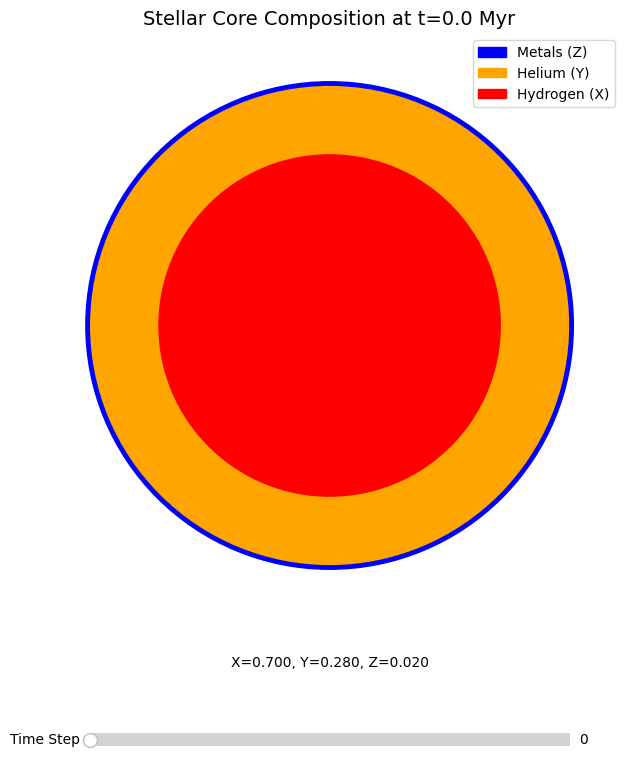

In [4]:
#code to produce the real-time visuals
"""
this part will work by plotting the stellar core on a 2D cartesian grid as rings of elements
as a simplification (just for visuals), the radius of each ring is just linearly proportional to the fraction of elements, instead of calculating volume
i.e.
r1 = X+Y+Z, r2 = Y+Z, r3 = Z
how to make a real-time sim? how to make a slider to go back and forth on the timeline?
how to plot circle & change color? likely matplotlib library
"""
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import Slider
import numpy as np

# Example data - replace with your actual simulation data
# Each row: [time (in Myr), X, Y, Z]
simulation_data = np.array([
    [0, 0.70, 0.28, 0.02],
    [100, 0.65, 0.32, 0.03],
    [200, 0.60, 0.36, 0.04],
    [300, 0.55, 0.40, 0.05],
    [400, 0.50, 0.44, 0.06],
    [500, 0.45, 0.47, 0.08],
    [600, 0.40, 0.50, 0.10],
])

# Enable interactive mode
plt.ion()

def plot_core(time_index, ax):
    """Plot the stellar core composition at a given time index"""
    ax.clear()
    
    # Get data for this timestep
    time, X, Y, Z = simulation_data[time_index]
    
    # Calculate radii (based on your spec)
    r1 = X
    r2 = X + Y
    r3 = 1.0  # X + Y + Z should equal 1
    
    # Create circles (plot from outside-in for proper layering)
    # Metals (outermost)
    circle3 = patches.Circle((0, 0), r3, color='blue', label='Metals (Z)')
    ax.add_patch(circle3)
    
    # Helium (middle)
    circle2 = patches.Circle((0, 0), r2, color='orange', label='Helium (Y)')
    ax.add_patch(circle2)
    
    # Hydrogen (innermost)
    circle1 = patches.Circle((0, 0), r1, color='red', label='Hydrogen (X)')
    ax.add_patch(circle1)
    
    # Set axis properties
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    ax.set_title(f'Stellar Core Composition at t={time:.1f} Myr', fontsize=14)
    ax.legend(loc='upper right')
    
    # Hide axes
    ax.axis('off')
    
    # Add text showing fractions
    ax.text(0, -1.4, f'X={X:.3f}, Y={Y:.3f}, Z={Z:.3f}', 
            ha='center', fontsize=10)

# Setup the figure and axis
fig = plt.figure(figsize=(8, 9))
ax = fig.add_axes([0.1, 0.25, 0.8, 0.65])  # [left, bottom, width, height]

# Initial plot
plot_core(0, ax)

# Create slider for timeline scrubbing
ax_slider = fig.add_axes([0.2, 0.1, 0.6, 0.03])
time_slider = Slider(
    ax=ax_slider,
    label='Time Step',
    valmin=0,
    valmax=len(simulation_data) - 1,
    valinit=0,
    valstep=1
)

# Update function for slider
def update(val):
    time_index = int(time_slider.val)
    plot_core(time_index, ax)
    fig.canvas.draw_idle()

time_slider.on_changed(update)

plt.show()